--- 1. Models Initialization ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- 2. Generating Embeddings ---
BGE Embeddings Shape:  (50, 384) (Expected: (50, 384))
MiniLM Embeddings Shape: (50, 384) (Expected: (50, 384))

--- 3. Computing Pairwise Cosine Similarity Matrices ---
BGE Matrix Shape: (50, 50)
MiniLM Matrix Shape: (50, 50)

--- 4. Spot Checking Key Intersecting Pairs ---
Exact Duplicates (Dog 0 ↔ Dog 1):
  -> BGE Score:    1.0000
  -> MiniLM Score: 1.0000
Semantic Duplicates (Dog 0 ↔ Canine 2):
  -> BGE Score:    0.7903
  -> MiniLM Score: 0.5943
Negation Check (Dog 0 ↔ Dog Negated 5):
  -> BGE Score:    0.8216
  -> MiniLM Score: 0.6851
Cross-Topic Noise (Dog 0 ↔ Mars Space Rover 40):
  -> BGE Score:    0.4669
  -> MiniLM Score: 0.0602


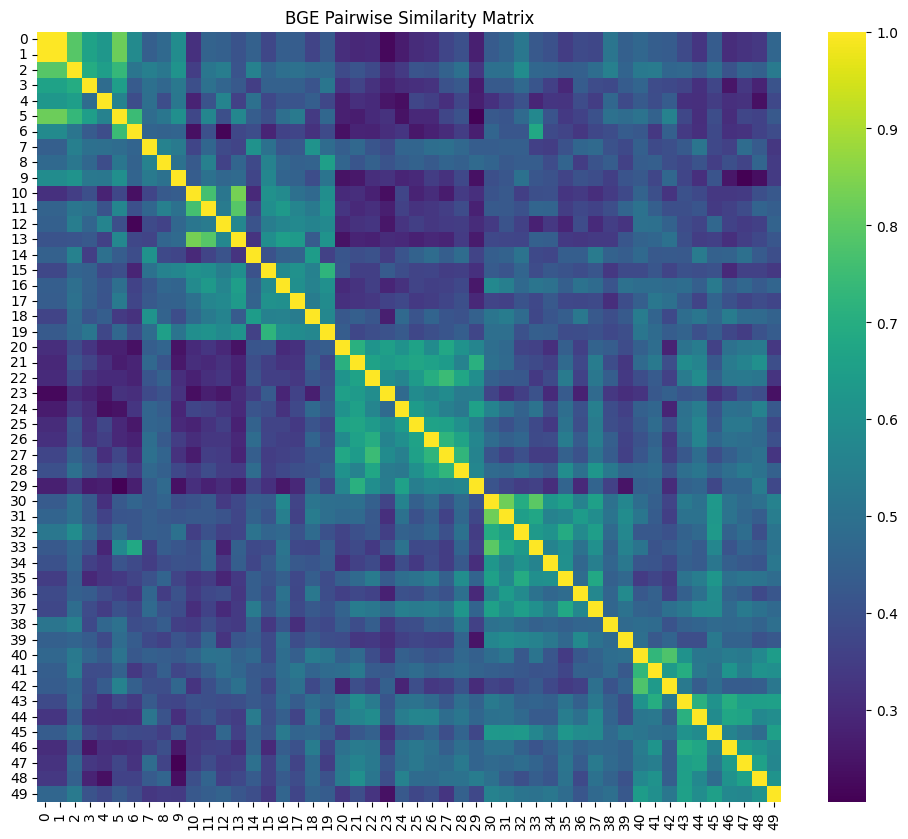

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns

def test_expanded_embeddings():
    # 1. Curate 50 sentences across mixed topics (Duplicates, Negations, Distinct topics)
    sentences = [
        # --- Topic 1: Dogs & Canines (0-9) ---
        "The dog ran through the park.",                      # 0: Base dog
        "The dog ran through the park.",                      # 1: Exact Duplicate
        "A canine sprinted across the field.",                # 2: Semantic Duplicate
        "The puppy played with a ball in the yard.",          # 3: Related
        "A hound chased the rabbit through the forest.",       # 4: Related
        "The dog did not run through the park.",              # 5: Negation
        "No dogs were seen in the park today.",               # 6: Negation
        "Canines are known to be loyal domesticated animals.", # 7: Informational
        "I need to take my dog to the vet for a checkup.",    # 8: Contextual
        "A stray dog barked loudly at the passing car.",      # 9: Contextual

        # --- Topic 2: Cats & Felines (10-19) ---
        "The cat slept soundly on the living room sofa.",     # 10: Base cat
        "A feline rested quietly on the couch.",              # 11: Semantic Duplicate
        "The kitten chased a laser pointer across the rug.",  # 12: Related
        "The cat did not sleep on the sofa.",                 # 13: Negation
        "Lions and tigers are apex predators in the wild.",   # 14: Broad Feline
        "My cat purrs whenever I scratch behind its ears.",   # 15: Contextual
        "A black cat stretched out under the warm sun.",       # 16: Contextual
        "The mouse scurried away before the cat noticed.",    # 17: Interaction
        "Felines possess sharp claws and excellent vision.",  # 18: Informational
        "I bought a new scratching post for my pet cat.",     # 19: Contextual

        # --- Topic 3: AI & Machine Learning (20-29) ---
        "I love studying machine learning algorithms.",        # 20: Base ML
        "Artificial intelligence is a fascinating field.",    # 21: Semantic Duplicate
        "Deep learning neural networks require massive data.", # 22: Related
        "I do not like machine learning or AI.",              # 23: Negation
        "Computers are getting smarter every single day.",    # 24: Broad
        "Python is heavily utilized in data science.",        # 25: Contextual
        "Large language models can generate human-like text.", # 26: Specific AI
        "Supervised learning involves training on labeled data.",# 27: Technical
        "We built a predictive model using linear regression.",# 28: Technical
        "AI will completely transform the healthcare industry.",# 29: Impact

        # --- Topic 4: Weather & Nature (30-39) ---
        "The weather is incredibly sunny and warm today.",    # 30: Base Weather
        "It is beautifully bright and hot outside right now.", # 31: Semantic Duplicate
        "It is raining heavily with loud thunder strikes.",   # 32: Opposite Weather
        "The weather is not sunny at all today.",             # 33: Negation
        "A thick blanket of fog rolled over the morning bay.", # 34: Related
        "Meteorologists predict a massive blizzard tonight.", # 35: Related
        "The autumn leaves are turning vibrant shades of red.",# 36: Nature
        "Climate change is causing unpredictable global weather.",# 37: Broad
        "We went for a long hike up the rocky mountain trail.",# 38: Activity
        "A gentle breeze rustled the green trees in the valley.",# 39: Nature

        # --- Topic 5: Space & Astronomy (40-49) ---
        "The rover landed safely on the surface of Mars.",     # 40: Base Space
        "A robotic explorer touched down on the red planet.", # 41: Semantic Duplicate
        "The rover did not land safely on Mars.",             # 42: Negation
        "Astronomers discovered a new exoplanet in deep space.",# 43: Related
        "The Milky Way galaxy contains billions of stars.",    # 44: Broad
        "A massive solar flare erupted from the sun's surface.",# 45: Related
        "The James Webb Telescope captured stunning cosmic images.",# 46: Specific
        "Black holes possess an inescapable gravitational pull.",# 47: Related
        "Astronauts on the ISS conduct vital microgravity research.",# 48: Contextual
        "The rocket launched into orbit from the space coast." # 49: Contextual
    ]

    print("--- 1. Models Initialization ---")
    bge = SentenceTransformer("BAAI/bge-small-en-v1.5")
    mini = SentenceTransformer("all-MiniLM-L6-v2")

    print("\n--- 2. Generating Embeddings ---")
    bge_embeddings = bge.encode(sentences)
    mini_embeddings = mini.encode(sentences)

    print(f"BGE Embeddings Shape:  {bge_embeddings.shape} (Expected: (50, 384))")
    print(f"MiniLM Embeddings Shape: {mini_embeddings.shape} (Expected: (50, 384))")

    print("\n--- 3. Computing Pairwise Cosine Similarity Matrices ---")

    # Fast matrix-multiplication based pairwise cosine similarity calculation
    # Formula: (A • B) / (||A|| * ||B||)

    # Normalize the vectors first to make dot product equivalent to cosine similarity
    bge_norm = bge_embeddings / np.linalg.norm(bge_embeddings, axis=1, keepdims=True)
    mini_norm = mini_embeddings / np.linalg.norm(mini_embeddings, axis=1, keepdims=True)

    bge_matrix = np.dot(bge_norm, bge_norm.T)
    mini_matrix = np.dot(mini_norm, mini_norm.T)

    print(f"BGE Matrix Shape: {bge_matrix.shape}")
    print(f"MiniLM Matrix Shape: {mini_matrix.shape}")

    print("\n--- 4. Spot Checking Key Intersecting Pairs ---")

    def report_sim(label, i, j):
        print(f"{label}:")
        print(f"  -> BGE Score:    {bge_matrix[i, j]:.4f}")
        print(f"  -> MiniLM Score: {mini_matrix[i, j]:.4f}")

    report_sim("Exact Duplicates (Dog 0 ↔ Dog 1)", 0, 1)
    report_sim("Semantic Duplicates (Dog 0 ↔ Canine 2)", 0, 2)
    report_sim("Negation Check (Dog 0 ↔ Dog Negated 5)", 0, 5)
    report_sim("Cross-Topic Noise (Dog 0 ↔ Mars Space Rover 40)", 0, 40)

    # Optional Visualization block
    # (Uncomment the lines below if you run this in a Jupyter notebook/local desktop to view maps)

    plt.figure(figsize=(12, 10))
    sns.heatmap(bge_matrix, cmap='viridis')
    plt.title('BGE Pairwise Similarity Matrix')
    plt.show()


if __name__ == "__main__":
    test_expanded_embeddings()

# OUTPUT:

# --- 2. Generating Embeddings ---
# BGE Embeddings Shape:  (50, 384) (Expected: (50, 384))
# MiniLM Embeddings Shape: (50, 384) (Expected: (50, 384))

# --- 3. Computing Pairwise Cosine Similarity Matrices ---
# BGE Matrix Shape: (50, 50)
# MiniLM Matrix Shape: (50, 50)

# --- 4. Spot Checking Key Intersecting Pairs ---
# Exact Duplicates (Dog 0 ↔ Dog 1):
#   -> BGE Score:    1.0000
#   -> MiniLM Score: 1.0000
# Semantic Duplicates (Dog 0 ↔ Canine 2):
#   -> BGE Score:    0.7903
#   -> MiniLM Score: 0.5943
# Negation Check (Dog 0 ↔ Dog Negated 5):
#   -> BGE Score:    0.8216
#   -> MiniLM Score: 0.6851
# Cross-Topic Noise (Dog 0 ↔ Mars Space Rover 40):
#   -> BGE Score:    0.4669
#   -> MiniLM Score: 0.0602

--- 1. Generating Embeddings ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BGE original shape: (50, 384)
MiniLM original shape: (50, 384)

--- 2. Reducing Dimensions via PCA to 2D ---
BGE reduced shape: (50, 2)
MiniLM reduced shape: (50, 2)

--- 3. Plotting the Cluster Distributions ---


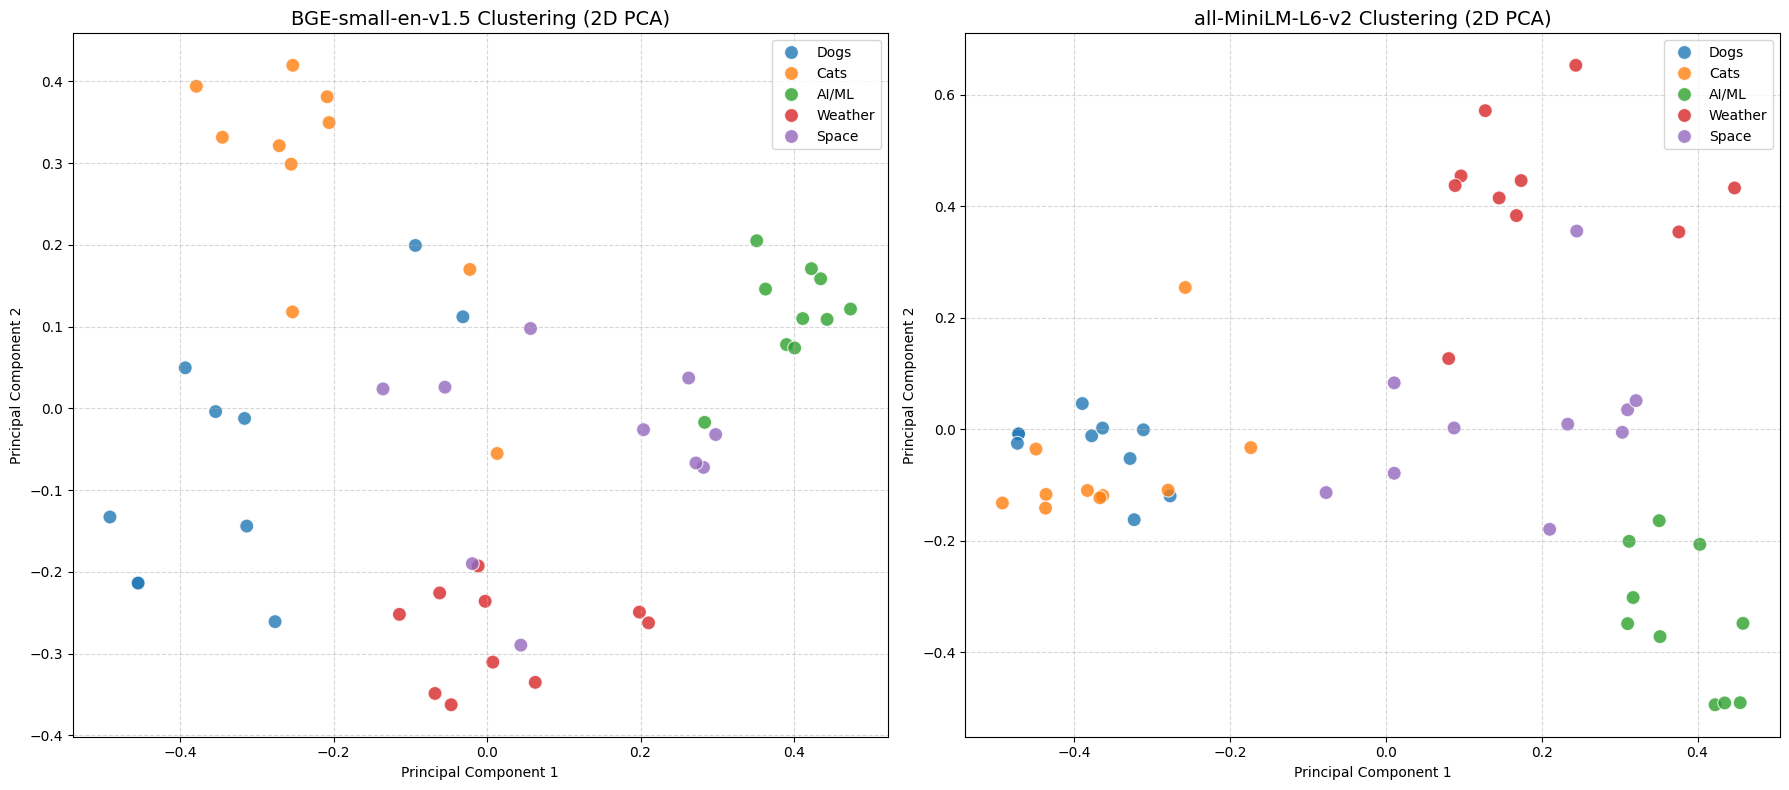

In [1]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def test_expanded_embeddings_with_pca():
    # 50 Curated sentences across 5 distinct topics
    sentences = [
        # --- Topic 1: Dogs & Canines (0-9) ---
        "The dog ran through the park.",
        "The dog ran through the park.",
        "A canine sprinted across the field.",
        "The puppy played with a ball in the yard.",
        "A hound chased the rabbit through the forest.",
        "The dog did not run through the park.",
        "No dogs were seen in the park today.",
        "Canines are known to be loyal domesticated animals.",
        "I need to take my dog to the vet for a checkup.",
        "A stray dog barked loudly at the passing car.",

        # --- Topic 2: Cats & Felines (10-19) ---
        "The cat slept soundly on the living room sofa.",
        "A feline rested quietly on the couch.",
        "The kitten chased a laser pointer across the rug.",
        "The cat did not sleep on the sofa.",
        "Lions and tigers are apex predators in the wild.",
        "My cat purrs whenever I scratch behind its ears.",
        "A black cat stretched out under the warm sun.",
        "The mouse scurried away before the cat noticed.",
        "Felines possess sharp claws and excellent vision.",
        "I bought a new scratching post for my pet cat.",

        # --- Topic 3: AI & Machine Learning (20-29) ---
        "I love studying machine learning algorithms.",
        "Artificial intelligence is a fascinating field.",
        "Deep learning neural networks require massive data.",
        "I do not like machine learning or AI.",
        "Computers are getting smarter every single day.",
        "Python is heavily utilized in data science.",
        "Large language models can generate human-like text.",
        "Supervised learning involves training on labeled data.",
        "We built a predictive model using linear regression.",
        "AI will completely transform the healthcare industry.",

        # --- Topic 4: Weather & Nature (30-39) ---
        "The weather is incredibly sunny and warm today.",
        "It is beautifully bright and hot outside right now.",
        "It is raining heavily with loud thunder strikes.",
        "The weather is not sunny at all today.",
        "A thick blanket of fog rolled over the morning bay.",
        "Meteorologists predict a massive blizzard tonight.",
        "The autumn leaves are turning vibrant shades of red.",
        "Climate change is causing unpredictable global weather.",
        "We went for a long hike up the rocky mountain trail.",
        "A gentle breeze rustled the green trees in the valley.",

        # --- Topic 5: Space & Astronomy (40-49) ---
        "The rover landed safely on the surface of Mars.",
        "A robotic explorer touched down on the red planet.",
        "The rover did not land safely on Mars.",
        "Astronomers discovered a new exoplanet in deep space.",
        "The Milky Way galaxy contains billions of stars.",
        "A massive solar flare erupted from the sun's surface.",
        "The James Webb Telescope captured stunning cosmic images.",
        "Black holes possess an inescapable gravitational pull.",
        "Astronauts on the ISS conduct vital microgravity research.",
        "The rocket launched into orbit from the space coast."
    ]

    # Create matching topic labels for coloring our plot
    topics = (["Dogs"] * 10) + (["Cats"] * 10) + (["AI/ML"] * 10) + (["Weather"] * 10) + (["Space"] * 10)

    print("--- 1. Generating Embeddings ---")
    bge = SentenceTransformer("BAAI/bge-small-en-v1.5")
    mini = SentenceTransformer("all-MiniLM-L6-v2")

    bge_embeddings = bge.encode(sentences)
    mini_embeddings = mini.encode(sentences)

    print(f"BGE original shape: {bge_embeddings.shape}")
    print(f"MiniLM original shape: {mini_embeddings.shape}")

    print("\n--- 2. Reducing Dimensions via PCA to 2D ---")
    # Initialize PCA to capture the top 2 linear directions of variance
    pca_bge = PCA(n_components=2, random_state=42)
    pca_mini = PCA(n_components=2, random_state=42)

    bge_2d = pca_bge.fit_transform(bge_embeddings)
    mini_2d = pca_mini.fit_transform(mini_embeddings)

    print(f"BGE reduced shape: {bge_2d.shape}")
    print(f"MiniLM reduced shape: {mini_2d.shape}")

    print("\n--- 3. Plotting the Cluster Distributions ---")
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Define distinct colors for the 5 clusters
    palette = {"Dogs": "#1f77b4", "Cats": "#ff7f0e", "AI/ML": "#2ca02c", "Weather": "#d62728", "Space": "#9467bd"}

    # Plot BGE
    sns.scatterplot(x=bge_2d[:, 0], y=bge_2d[:, 1], hue=topics, palette=palette, s=100, ax=axes[0], alpha=0.8)
    axes[0].set_title("BGE-small-en-v1.5 Clustering (2D PCA)", fontsize=14)
    axes[0].set_xlabel("Principal Component 1")
    axes[0].set_ylabel("Principal Component 2")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # Plot MiniLM
    sns.scatterplot(x=mini_2d[:, 0], y=mini_2d[:, 1], hue=topics, palette=palette, s=100, ax=axes[1], alpha=0.8)
    axes[1].set_title("all-MiniLM-L6-v2 Clustering (2D PCA)", fontsize=14)
    axes[1].set_xlabel("Principal Component 1")
    axes[1].set_ylabel("Principal Component 2")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    test_expanded_embeddings_with_pca()

In [2]:
import numpy as np
from sentence_transformers import SentenceTransformer


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def analyze_failure_cases():
    # Load both models
    bge = SentenceTransformer("BAAI/bge-small-en-v1.5")
    mini = SentenceTransformer("all-MiniLM-L6-v2")

    # Define the failure case pairs
    cases = {
        "Failure Case 1: Negation": {
            "sent_A": "The drone landed safely.",
            "sent_B": "The drone did not land safely.",
            "paradox": "Logically opposite meanings, but highly overlapping vocabulary.",
        },
        "Failure Case 2: Synonym Pair": {
            "sent_A": "The car accelerated quickly.",
            "sent_B": "The automobile sped up rapidly.",
            "paradox": "Identical meaning, but zero overlapping vocabulary words.",
        },
        "Failure Case 3: Antonyms (Opposites)": {
            "sent_A": "The server is online.",
            "sent_B": "The server is offline.",
            "paradox": "Direct logical contradiction packed into a single flipped token.",
        },
    }

    print("=== EVALUATING EMBEDDING FAILURE CASES ===\n")

    for title, data in cases.items():
        print(f"--- {title} ---")
        print(f"  Sentence A: '{data['sent_A']}'")
        print(f"  Sentence B: '{data['sent_B']}'")
        print(f"  The Issue:  {data['paradox']}")

        # Generate vectors
        bge_A = bge.encode(data["sent_A"])
        bge_B = bge.encode(data["sent_B"])

        mini_A = mini.encode(data["sent_A"])
        mini_B = mini.encode(data["sent_B"])

        # Calculate Cosine Similarities
        bge_sim = cosine_similarity(bge_A, bge_B)
        mini_sim = cosine_similarity(mini_A, mini_B)

        print(f"  -> BGE Cosine Similarity:    {bge_sim:.4f}")
        print(f"  -> MiniLM Cosine Similarity: {mini_sim:.4f}\n")


if __name__ == "__main__":
    analyze_failure_cases()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

=== EVALUATING EMBEDDING FAILURE CASES ===

--- Failure Case 1: Negation ---
  Sentence A: 'The drone landed safely.'
  Sentence B: 'The drone did not land safely.'
  The Issue:  Logically opposite meanings, but highly overlapping vocabulary.
  -> BGE Cosine Similarity:    0.8578
  -> MiniLM Cosine Similarity: 0.8205

--- Failure Case 2: Synonym Pair ---
  Sentence A: 'The car accelerated quickly.'
  Sentence B: 'The automobile sped up rapidly.'
  The Issue:  Identical meaning, but zero overlapping vocabulary words.
  -> BGE Cosine Similarity:    0.9322
  -> MiniLM Cosine Similarity: 0.8111

--- Failure Case 3: Antonyms (Opposites) ---
  Sentence A: 'The server is online.'
  Sentence B: 'The server is offline.'
  The Issue:  Direct logical contradiction packed into a single flipped token.
  -> BGE Cosine Similarity:    0.8881
  -> MiniLM Cosine Similarity: 0.7880

